In [9]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score
)
from PIL import Image

# ─── Configuración ────────────────────────────────────
PROJECT_ROOT  = Path("C:/Projects/raptor_australia")
PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed"
MODELS_DIR    = PROJECT_ROOT / "models"
RESULTS_DIR   = PROJECT_ROOT / "results"

device = torch.device("cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"✅ Dispositivo: {device}")

# ─── Parámetros ───────────────────────────────────────
IMG_SIZE    = 380
BATCH_SIZE  = 8
NUM_CLASSES = 8

CLASS_NAMES = [
    "Wedge-tailed Eagle",
    "Peregrine Falcon",
    "Spotted Harrier",
    "Brown Goshawk",
    "Nankeen Kestrel",
    "Black-shouldered Kite",
    "Square-tailed Kite",
    "Little Eagle"
]

CLASS_KEYS = [
    "aquila_audax",
    "falco_peregrinus",
    "circus_assimilis",
    "tachyspiza_fasciata",
    "falco_cenchroides",
    "elanus_axillaris",
    "lophoictinia_isura",
    "hieraaetus_morphnoides"
]

# ─── Transformación de evaluación ─────────────────────
eval_transform = transforms.Compose([
    transforms.Resize((420, 420)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Configuración cargada")

✅ Dispositivo: cuda
✅ Configuración cargada


In [10]:
class AustralianRaptorCNN(nn.Module):
    def __init__(self, num_classes=8, dropout_rate=0.4):
        super(AustralianRaptorCNN, self).__init__()
        self.backbone = models.efficientnet_b4(
            weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
        )
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# Cargar modelo entrenado
model = AustralianRaptorCNN(num_classes=NUM_CLASSES).to(device)

checkpoint = torch.load(
    MODELS_DIR / "best_model.pth",
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"✅ Modelo cargado")
print(f"   Guardado en época: {checkpoint['epoch']}")
print(f"   Val F1 al guardar: {checkpoint['val_f1']:.4f}")
print(f"   Val Acc al guardar: {checkpoint['val_acc']:.4f}")

✅ Modelo cargado
   Guardado en época: 33
   Val F1 al guardar: 0.7825
   Val Acc al guardar: 0.8149


In [11]:
# Cargar test dataset
test_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "test"),
    transform=eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"📊 Test set: {len(test_dataset)} imágenes")
print(f"   Clases detectadas: {test_dataset.classes}\n")

# Evaluación completa
all_preds  = []
all_labels = []
all_probs  = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ─── Métricas globales ────────────────────────────────
accuracy   = accuracy_score(all_labels, all_preds)
f1_macro   = f1_score(all_labels, all_preds, average="macro")
f1_weighted= f1_score(all_labels, all_preds, average="weighted")

print("="*55)
print("  RESULTADOS EN TEST SET")
print("="*55)
print(f"  Accuracy global:    {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  F1-Score macro:     {f1_macro:.4f}")
print(f"  F1-Score weighted:  {f1_weighted:.4f}")
print("="*55)

# Verificar si se cumplieron los objetivos
print("\n🎯 Verificación de objetivos:")
print(f"  Accuracy ≥ 80%:  "
      f"{'✅' if accuracy >= 0.80 else '⚠️ '} {accuracy*100:.1f}%")
print(f"  F1 macro ≥ 0.75: "
      f"{'✅' if f1_macro >= 0.75 else '⚠️ '} {f1_macro:.4f}")

📊 Test set: 490 imágenes
   Clases detectadas: ['aquila_audax', 'circus_assimilis', 'elanus_axillaris', 'falco_cenchroides', 'falco_peregrinus', 'hieraaetus_morphnoides', 'lophoictinia_isura', 'tachyspiza_fasciata']

  RESULTADOS EN TEST SET
  Accuracy global:    0.8082  (80.8%)
  F1-Score macro:     0.7840
  F1-Score weighted:  0.8044

🎯 Verificación de objetivos:
  Accuracy ≥ 80%:  ✅ 80.8%
  F1 macro ≥ 0.75: ✅ 0.7840


In [12]:
print("📋 REPORTE POR ESPECIE\n")

report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Mostrar solo las clases (no promedios)
clases_df = report_df.loc[CLASS_NAMES].copy()
clases_df.index = [name[:22] for name in CLASS_NAMES]

print(f"{'Especie':<24} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8} {'Imágenes':>10}")
print("-" * 64)

for nombre in CLASS_NAMES:
    nombre_corto = nombre[:22]
    row = report_df.loc[nombre]
    objetivo = "✅" if row["f1-score"] >= 0.70 else "⚠️ "
    print(f"{nombre_corto:<24} {row['precision']:>10.3f} "
          f"{row['recall']:>8.3f} {row['f1-score']:>8.3f} "
          f"{int(row['support']):>8}  {objetivo}")

print("-" * 64)
print(f"{'Macro avg':<24} "
      f"{report['macro avg']['precision']:>10.3f} "
      f"{report['macro avg']['recall']:>8.3f} "
      f"{report['macro avg']['f1-score']:>8.3f}")

# Guardar reporte
clases_df.to_csv(RESULTS_DIR / "test_report.csv")
print(f"\n✅ Reporte guardado en results/test_report.csv")

📋 REPORTE POR ESPECIE

Especie                   Precision   Recall       F1   Imágenes
----------------------------------------------------------------
Wedge-tailed Eagle            0.750    0.660    0.702       50  ✅
Peregrine Falcon              0.917    0.550    0.688       40  ⚠️ 
Spotted Harrier               0.928    0.939    0.933       82  ✅
Brown Goshawk                 0.759    0.913    0.829       69  ✅
Nankeen Kestrel               0.720    0.783    0.750       46  ✅
Black-shouldered Kite         0.877    0.810    0.842       79  ✅
Square-tailed Kite            0.740    0.914    0.818       81  ✅
Little Eagle                  0.818    0.628    0.711       43  ✅
----------------------------------------------------------------
Macro avg                     0.814    0.775    0.784

✅ Reporte guardado en results/test_report.csv


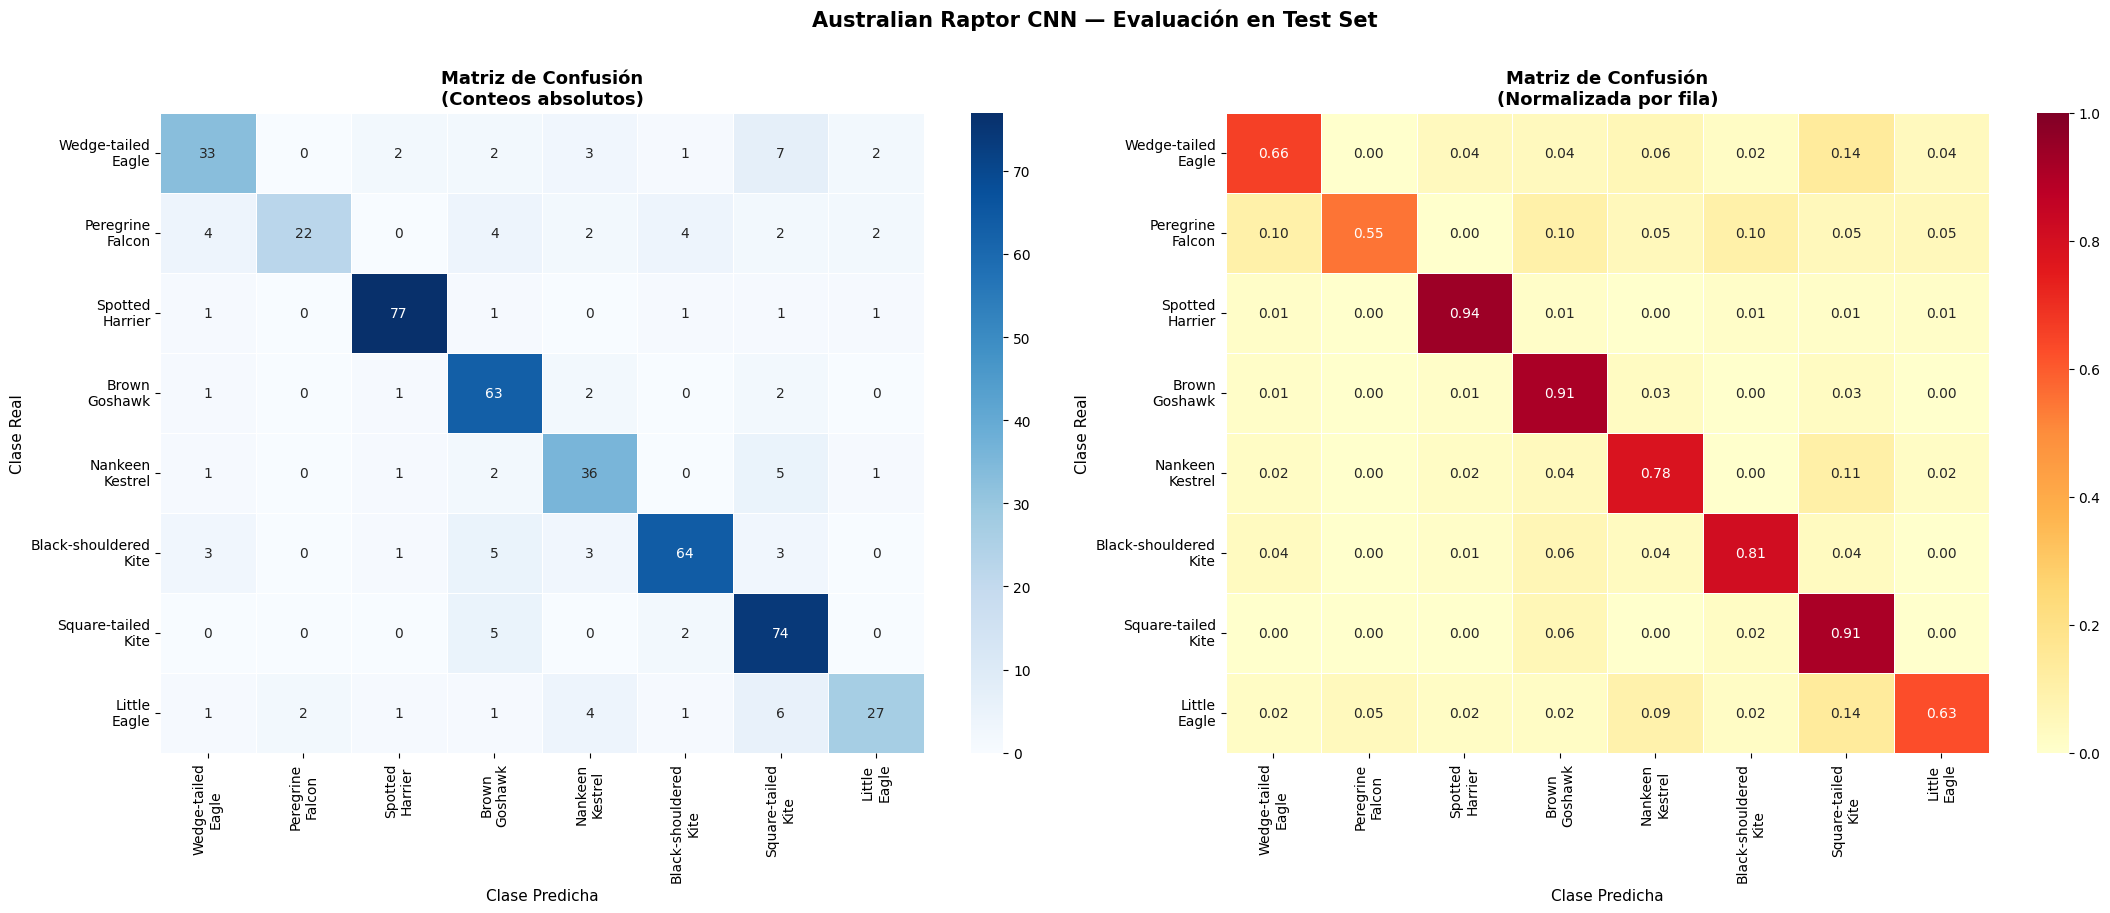

✅ Matriz guardada en results/confusion_matrix.png


In [13]:
# Calcular matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Normalizar por fila (porcentaje por clase real)
cm_normalized = cm.astype("float") / cm.sum(axis=1,
                                             keepdims=True)

# Nombres cortos para el plot
nombres_cortos = [
    "Wedge-tailed\nEagle",
    "Peregrine\nFalcon",
    "Spotted\nHarrier",
    "Brown\nGoshawk",
    "Nankeen\nKestrel",
    "Black-shouldered\nKite",
    "Square-tailed\nKite",
    "Little\nEagle"
]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# ─── Matriz con conteos ───────────────────────────────
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nombres_cortos,
    yticklabels=nombres_cortos,
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title("Matriz de Confusión\n(Conteos absolutos)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Clase Real", fontsize=11)
axes[0].set_xlabel("Clase Predicha", fontsize=11)

# ─── Matriz normalizada (porcentajes) ─────────────────
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=nombres_cortos,
    yticklabels=nombres_cortos,
    ax=axes[1],
    linewidths=0.5,
    vmin=0,
    vmax=1
)
axes[1].set_title("Matriz de Confusión\n(Normalizada por fila)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Clase Real", fontsize=11)
axes[1].set_xlabel("Clase Predicha", fontsize=11)

plt.suptitle(
    "Australian Raptor CNN — Evaluación en Test Set",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    str(RESULTS_DIR / "confusion_matrix.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Matriz guardada en results/confusion_matrix.png")

C:\Users\hogwa\AppData\Local\Temp\ipykernel_40352\1946707582.py:56: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hogwa\AppData\Local\Temp\ipykernel_40352\1946707582.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hogwa\AppData\Local\Temp\ipykernel_40352\1946707582.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(
C:\Users\hogwa\AppData\Local\Temp\ipykernel_40352\1946707582.py:57: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(
c:\Users\hogwa\anaconda3\envs\raptor_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hogwa\anaconda3\envs\raptor_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

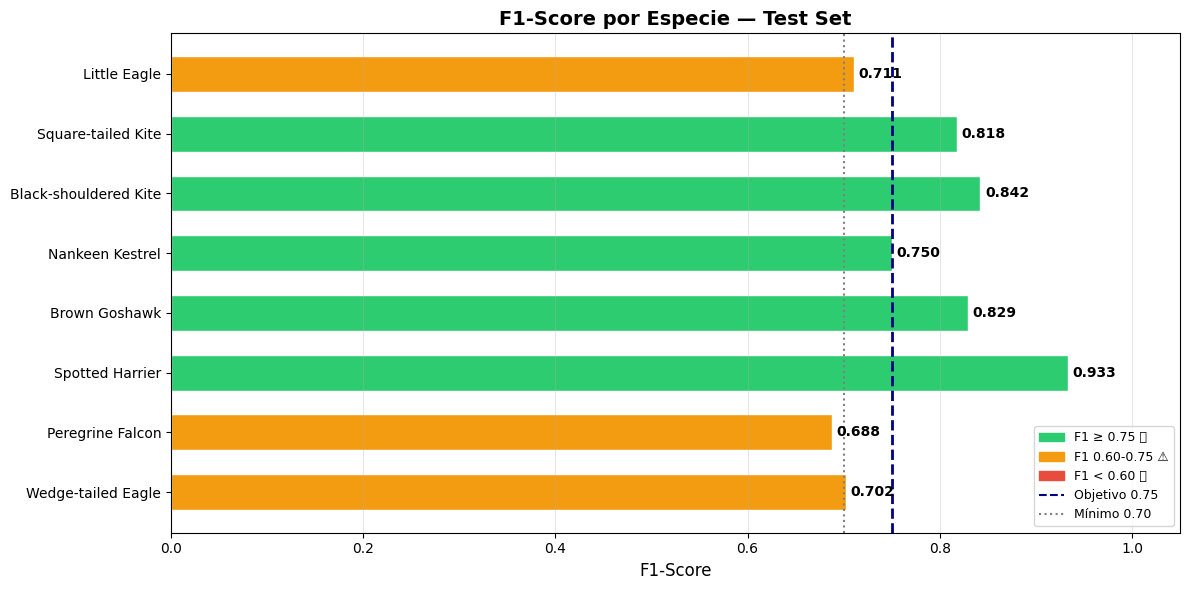

✅ Gráfica guardada en results/f1_por_especie.png


In [14]:
f1_por_especie = [
    report[nombre]["f1-score"]
    for nombre in CLASS_NAMES
]

colores = [
    "#2ECC71" if f1 >= 0.75 else
    "#F39C12" if f1 >= 0.60 else
    "#E74C3C"
    for f1 in f1_por_especie
]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    [n[:30] for n in CLASS_NAMES],
    f1_por_especie,
    color=colores,
    edgecolor="white",
    height=0.6
)

# Línea de objetivo
ax.axvline(x=0.75, color="navy", linestyle="--",
           linewidth=2, label="Objetivo F1 ≥ 0.75")
ax.axvline(x=0.70, color="gray", linestyle=":",
           linewidth=1.5, label="Mínimo F1 ≥ 0.70")

# Etiquetas de valor
for bar, f1 in zip(bars, f1_por_especie):
    ax.text(
        f1 + 0.005, bar.get_y() + bar.get_height() / 2,
        f"{f1:.3f}",
        va="center", fontsize=10, fontweight="bold"
    )

# Leyenda de colores
legend_elements = [
    mpatches.Patch(color="#2ECC71", label="F1 ≥ 0.75 ✅"),
    mpatches.Patch(color="#F39C12", label="F1 0.60-0.75 ⚠️"),
    mpatches.Patch(color="#E74C3C", label="F1 < 0.60 ❌")
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color="navy",
               linestyle="--", label="Objetivo 0.75"),
    plt.Line2D([0], [0], color="gray",
               linestyle=":", label="Mínimo 0.70")
], loc="lower right", fontsize=9)

ax.set_xlim(0, 1.05)
ax.set_xlabel("F1-Score", fontsize=12)
ax.set_title("F1-Score por Especie — Test Set",
             fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    str(RESULTS_DIR / "f1_por_especie.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Gráfica guardada en results/f1_por_especie.png")

In [15]:
# Reporte JSON con todos los resultados
reporte_final = {
    "modelo": "EfficientNetB4",
    "dataset": "iNaturalist Australia",
    "total_test_images": len(test_dataset),
    "metricas_globales": {
        "accuracy":     round(float(accuracy), 4),
        "f1_macro":     round(float(f1_macro), 4),
        "f1_weighted":  round(float(f1_weighted), 4)
    },
    "objetivos": {
        "accuracy_80":  bool(accuracy >= 0.80),
        "f1_macro_75":  bool(f1_macro >= 0.75)
    },
    "por_especie": {
        nombre: {
            "precision": round(report[nombre]["precision"], 4),
            "recall":    round(report[nombre]["recall"], 4),
            "f1":        round(report[nombre]["f1-score"], 4),
            "support":   int(report[nombre]["support"])
        }
        for nombre in CLASS_NAMES
    }
}

import json
with open(RESULTS_DIR / "reporte_final.json", "w") as f:
    json.dump(reporte_final, f, indent=2, ensure_ascii=False)

print("="*55)
print("  RESUMEN EJECUTIVO")
print("="*55)
print(f"  Accuracy:    {accuracy*100:.1f}%")
print(f"  F1 macro:    {f1_macro:.4f}")
print(f"  F1 weighted: {f1_weighted:.4f}")
print("="*55)
print(f"\n  Objetivo accuracy ≥ 80%:  "
      f"{'✅ CUMPLIDO' if accuracy >= 0.80 else '⚠️  NO cumplido'}")
print(f"  Objetivo F1 ≥ 0.75:       "
      f"{'✅ CUMPLIDO' if f1_macro >= 0.75 else '⚠️  NO cumplido'}")
print(f"\n✅ Reporte guardado en results/reporte_final.json")
print(f"\n🎯 Evaluación completa. Modelo listo para la GUI.")

  RESUMEN EJECUTIVO
  Accuracy:    80.8%
  F1 macro:    0.7840
  F1 weighted: 0.8044

  Objetivo accuracy ≥ 80%:  ✅ CUMPLIDO
  Objetivo F1 ≥ 0.75:       ✅ CUMPLIDO

✅ Reporte guardado en results/reporte_final.json

🎯 Evaluación completa. Modelo listo para la GUI.
